In [1]:
import os
import json
import random
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer
from gap.data import OxfordPetDataset
from gap.purify import purify_ddpm
from gap.purification.train_scriptv2 import GaussianDiffusion, HyperConfig, UNetLite
from gap.purification.dae_train_script import HyperConfig as DAEHyperConfig
from gap.purification.dae_train_script import ShallowDAE

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

clf_metadata_path = os.path.join(RUN_DIR, "pets_binary_metadata.json")
clf_weights_path = os.path.join(RUN_DIR, "pets_binary_classifier.pth")

dae_metadata_path = os.path.join(RUN_DIR, "pets_dae/best_model.pt")
dm_metadata_path = os.path.join(RUN_DIR, "pets_diffusion/best_model.pt")

with open(clf_metadata_path, "r") as f:
    clf_best_model = json.load(f)

clf_best_config = clf_best_model["model_config"]
print(f"Loaded config: {clf_best_config}")

Using device: mps
Loaded config: {'lr': 0.0002480508929795373, 'channels': 48, 'depth': 6, 'optimizer': 'adam', 'weight_decay': 0.0005}


In [3]:
# Instantiate the model using the weights and metadata loaded
clf_trained_model = ScalableResNetLite(
    num_classes=2, channels=clf_best_config["channels"], depth=clf_best_config["depth"]
).to(device)

clf_trained_model.load_state_dict(
    torch.load(clf_weights_path, map_location=device, weights_only=True)
)
clf_trained_model.eval()
print("Classification model loaded successfully!")

Classification model loaded successfully!


In [4]:
def load_diffusion_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    hcfg_dict = checkpoint["hcfg"]
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    diffusion = GaussianDiffusion(unet, num_timesteps=hcfg.num_timesteps).to(device)
    diffusion.eval()
    
    return diffusion, hcfg

def load_dae_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    hcfg_dict = checkpoint["hcfg"]
    hcfg = DAEHyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparamters: {hcfg}")

    dae = ShallowDAE(in_channels=in_channels,
        base_channels=hcfg.base_channels,
        bottleneck_dim=hcfg.bottleneck_dim,
        dropout=hcfg.dropout,
        noise_std=hcfg.noise_std
    ).to(device)

    dae.load_state_dict(checkpoint["model"])
    dae.eval()

    return dae, hcfg

In [5]:
dm, dm_config = load_diffusion_model(RUN_DIR + "/pets_diffusion/best_model.pt")
dae, dae_config = load_dae_model(RUN_DIR + "/pets_dae/best_model.pt")

Loaded Hyperparameters: HyperConfig(base_channels=32, channel_mults=(1, 2, 2), num_res_blocks=1, dropout=0.0, lr=0.0003, batch_size=32, num_timesteps=200)
Loaded Hyperparamters: HyperConfig(base_channels=32, bottleneck_dim=256, dropout=0.1, lr=0.0003, batch_size=32, noise_std=0.05)


In [6]:
transform_test = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
root = "../oxford-iiit-pet/images"

# Load the full dataset directly with the test transform since we only care about evaluating here
full_dataset = OxfordPetDataset(root, binary=True, transform=transform_test)
print("Classes:", len(full_dataset.classes))

total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

# Split the dataset using a fixed seed to guarantee the exact same test set every time
_, _, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

print(f"Test Set Size: {len(test_dataset)}")

eval_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True
)
print("Data loaded successfully! Ready for adversarial generation.")

Classes: 2
Test Set Size: 1109
Data loaded successfully! Ready for adversarial generation.


In [7]:
attacker = AdversarialAttacker(
    clf_trained_model, 
    device=device,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

original_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Filtering complete. Accuracy 80.97.


In [8]:
# Generate datasets
fgsm_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="fgsm", epsilon=1 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="pgd", epsilon=1 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [9]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/pets_binary_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/pets_binary_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/pets_binary_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/pets_binary_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [9]:
PETS_BINARY_CLASSES = ['dog', 'cat']

def get_predictions_and_probs(model, dataloader, device):
    """Iterates through the dataloader to get true labels, predictions, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def print_metrics(dataset_name, y_true, y_pred, y_prob):
    """Calculates and prints comprehensive metrics for binary classification."""
    acc = accuracy_score(y_true, y_pred)
    
    # Using 'binary' average is the standard for 2-class problems
    prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
    
    # For binary ROC-AUC, pass ONLY the probabilities of the positive class (index 1)
    # Remove the multi_class='ovr' parameter
    roc_auc = roc_auc_score(y_true, y_prob[:, 1])
    
    print(f"--- {dataset_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

In [10]:
def diff_purify_dataset(dataloader, model, clf_model, device, ratios=None):
    # t_max_ratio controls how far into the diffusion process we go.
    # 0.15 to 0.20 is usually the sweet spot. Too low = adversarial 
    # noise survives. Too high = image structure is destroyed.
    if not ratios:
        ratios = [0.2375, 0.25, 0.2625, 0.275]
    best_ratio = 0.05
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    for ratio in ratios:
        purified_images = []
        labels_list = []

        for images, labels in dataloader:
            # Get the full trajectory, take the last frame
            traj = purify_ddpm(images, model, t_max_ratio=ratio, device=device)
            # traj is returned as a numpy array of shape [steps, B, C, H, W]
            final_step = torch.tensor(traj[-1], dtype=torch.float32) 
            # Ensure shape integrity for batches of 1
            if final_step.dim() == 3:
                final_step = final_step.unsqueeze(0) 
            # Clamp to [-1, 1] just in case the reverse process drifted slightly
            final_step = torch.clamp(final_step, -1.0, 1.0)

            purified_images.append(final_step)
            labels_list.append(labels)

        diff_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
        diff_purified_loader = DataLoader(diff_purified_dataset, batch_size=128, shuffle=False)

        y, preds, _ = get_predictions_and_probs(clf_model, diff_purified_loader, device)
        acc = accuracy_score(y, preds)
        print(f"Ratio: {ratio}. Accuracy: {acc}")
        if acc > best_acc:
            best_purified_images = purified_images
            best_labels_list = labels_list
            best_ratio = ratio
            best_acc = acc

    print(f"Best Ratio: {best_ratio}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)

def dae_purify_dataset(dataloader, model, clf_model, device):
    # Explicitly move models to the target device (CPU, CUDA, or MPS)
    model = model.to(device)
    clf_model = clf_model.to(device)
    
    model.eval()
    clf_model.eval()
    
    # We sweep over a few noise scales. 0.0 means a direct forward pass.
    # Higher values add stochastic noise to break the adversarial gradients before reconstruction.
    noise_stds = np.linspace(0, 0.1, 11)
    best_std = 0.0
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    with torch.no_grad():
        for std in noise_stds:
            purified_images = []
            labels_list = []

            for images, labels in dataloader:
                images = images.to(device)
                
                # 1. Optionally inject noise to disrupt the adversarial attack
                if std > 0:
                    noisy_images = images + torch.randn_like(images) * std
                else:
                    noisy_images = images

                # 2. Single-step manifold projection via the DAE
                recons = model(noisy_images)
                
                # 3. Clamp back to valid image range [-1, 1]
                recons = torch.clamp(recons, -1.0, 1.0)

                purified_images.append(recons.cpu())
                labels_list.append(labels.cpu())

            # Create a temporary loader to evaluate this specific noise scale
            dae_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
            dae_purified_loader = DataLoader(dae_purified_dataset, batch_size=128, shuffle=False)

            # Evaluate against the classifier
            y, preds, _ = get_predictions_and_probs(clf_model, dae_purified_loader, device)
            acc = accuracy_score(y, preds)
            
            print(f"Noise STD: {std}. Accuracy: {acc}")
            
            if acc > best_acc:
                best_purified_images = purified_images
                best_labels_list = labels_list
                best_std = std
                best_acc = acc

    print(f"Best Noise STD: {best_std}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)

In [11]:
dae_purified_fgsm_images, dae_purified_fgsm_labels = dae_purify_dataset(fgsm_loader, dae, clf_trained_model, device)
dae_purified_pgd_images, dae_purified_pgd_labels = dae_purify_dataset(pgd_loader, dae, clf_trained_model, device)

Noise STD: 0.0. Accuracy: 0.6893095768374164
Noise STD: 0.01. Accuracy: 0.688195991091314
Noise STD: 0.02. Accuracy: 0.6870824053452116
Noise STD: 0.03. Accuracy: 0.6904231625835189
Noise STD: 0.04. Accuracy: 0.6848552338530067
Noise STD: 0.05. Accuracy: 0.6904231625835189
Noise STD: 0.06. Accuracy: 0.6904231625835189
Noise STD: 0.07. Accuracy: 0.688195991091314
Noise STD: 0.08. Accuracy: 0.6971046770601337
Noise STD: 0.09. Accuracy: 0.6926503340757239
Noise STD: 0.1. Accuracy: 0.688195991091314
Best Noise STD: 0.08. Best Accuracy: 0.6971046770601337
Noise STD: 0.0. Accuracy: 0.6904231625835189
Noise STD: 0.01. Accuracy: 0.6915367483296214
Noise STD: 0.02. Accuracy: 0.6893095768374164
Noise STD: 0.03. Accuracy: 0.6904231625835189
Noise STD: 0.04. Accuracy: 0.6915367483296214
Noise STD: 0.05. Accuracy: 0.6915367483296214
Noise STD: 0.06. Accuracy: 0.6948775055679287
Noise STD: 0.07. Accuracy: 0.7015590200445434
Noise STD: 0.08. Accuracy: 0.6937639198218263
Noise STD: 0.09. Accuracy: 0.6

In [11]:
dae_purified_save_dir = "../datasets/clean/pets_binary/dae"
os.makedirs(dae_purified_save_dir, exist_ok=True)

In [13]:
torch.save({"images": dae_purified_fgsm_images, "labels": dae_purified_fgsm_labels}, os.path.join(dae_purified_save_dir, "pets_binary_purified_fgsm.pt"))
torch.save({"images": dae_purified_pgd_images, "labels": dae_purified_pgd_labels}, os.path.join(dae_purified_save_dir, "pets_binary_purified_pgd.pt"))

In [12]:
dae_purified_fgsm_data_dict = torch.load(
    os.path.join(dae_purified_save_dir, "pets_binary_purified_fgsm.pt"), weights_only=True
)
dae_purified_fgsm_dataset = TensorDataset(dae_purified_fgsm_data_dict["images"], dae_purified_fgsm_data_dict["labels"])
dae_purified_fgsm_loader = DataLoader(dae_purified_fgsm_dataset, batch_size=128, shuffle=False)

dae_purified_pgd_data_dict = torch.load(
    os.path.join(dae_purified_save_dir, "pets_binary_purified_pgd.pt"), weights_only=True
)
dae_purified_pgd_dataset = TensorDataset(dae_purified_pgd_data_dict["images"], dae_purified_pgd_data_dict["labels"])
dae_purified_pgd_loader = DataLoader(dae_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders (DAE) are ready.")

Purified DataLoaders (DAE) are ready.


In [16]:
diff_purified_fgsm_images, diff_purified_fgsm_labels = diff_purify_dataset(fgsm_loader, dm, clf_trained_model, device)
diff_purified_pgd_images, diff_purified_pgd_labels = diff_purify_dataset(pgd_loader, dm, clf_trained_model, device, ratios=[0.2625, 0.275, 0.2875, 0.3])

Ratio: 0.2375. Accuracy: 0.7394209354120267
Ratio: 0.25. Accuracy: 0.732739420935412
Ratio: 0.2625. Accuracy: 0.7416481069042317
Ratio: 0.275. Accuracy: 0.7316258351893096
Best Ratio: 0.2625. Best Accuracy: 0.7416481069042317
Ratio: 0.2625. Accuracy: 0.7405345211581291
Ratio: 0.275. Accuracy: 0.7461024498886414
Ratio: 0.2875. Accuracy: 0.734966592427617
Ratio: 0.3. Accuracy: 0.7505567928730512
Best Ratio: 0.3. Best Accuracy: 0.7505567928730512


In [13]:
diff_purified_save_dir = "../datasets/clean/pets_binary/diff"
os.makedirs(diff_purified_save_dir, exist_ok=True)

In [20]:
torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "pets_binary_purified_fgsm.pt"))
torch.save({"images": diff_purified_pgd_images, "labels": diff_purified_pgd_labels}, os.path.join(diff_purified_save_dir, "pets_binary_purified_pgd.pt"))

In [14]:
diff_purified_fgsm_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "pets_binary_purified_fgsm.pt"), weights_only=True
)
diff_purified_fgsm_dataset = TensorDataset(diff_purified_fgsm_data_dict["images"], diff_purified_fgsm_data_dict["labels"])
diff_purified_fgsm_loader = DataLoader(diff_purified_fgsm_dataset, batch_size=128, shuffle=False)

diff_purified_pgd_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "pets_binary_purified_pgd.pt"), weights_only=True
)
diff_purified_pgd_dataset = TensorDataset(diff_purified_pgd_data_dict["images"], diff_purified_pgd_data_dict["labels"])
diff_purified_pgd_loader = DataLoader(diff_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders are ready.")

Purified DataLoaders are ready.


In [15]:
print("Evaluating Original Data...")
original_y, original_preds, original_probs = get_predictions_and_probs(clf_trained_model, original_loader, device)

print("Evaluating FGSM Data...")
fgsm_y, fgsm_preds, fgsm_probs = get_predictions_and_probs(clf_trained_model, fgsm_loader, device)

print("Evaluating PGD Data...")
pgd_y, pgd_preds, pgd_probs = get_predictions_and_probs(clf_trained_model, pgd_loader, device)

print("Evaluating DAE Purified FGSM Data...")
dae_purified_fgsm_y, dae_purified_fgsm_preds, dae_purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, dae_purified_fgsm_loader, device)

print("Evaluating DAE Purified PGD Data...")
dae_purified_pgd_y, dae_purified_pgd_preds, dae_purified_pgd_probs = get_predictions_and_probs(clf_trained_model, dae_purified_pgd_loader, device)

print("Evaluating Diff Purified FGSM Data...")
diff_purified_fgsm_y, diff_purified_fgsm_preds, diff_purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, diff_purified_fgsm_loader, device)

print("Evaluating Diff Purified PGD Data...")
diff_purified_pgd_y, diff_purified_pgd_preds, diff_purified_pgd_probs = get_predictions_and_probs(clf_trained_model, diff_purified_pgd_loader, device)

print_metrics("Original Subset", original_y, original_preds, original_probs)
print_metrics("FGSM Adversarial", fgsm_y, fgsm_preds, fgsm_probs)
print_metrics("PGD Adversarial", pgd_y, pgd_preds, pgd_probs)
print_metrics("DAE Purified FGSM", dae_purified_fgsm_y, dae_purified_fgsm_preds, dae_purified_fgsm_probs)
print_metrics("DAE Purified PGD", dae_purified_pgd_y, dae_purified_pgd_preds, dae_purified_pgd_probs)
print_metrics("Diff Purified FGSM", diff_purified_fgsm_y, diff_purified_fgsm_preds, diff_purified_fgsm_probs)
print_metrics("Diff Purified PGD", diff_purified_pgd_y, diff_purified_pgd_preds, diff_purified_pgd_probs)

Evaluating Original Data...
Evaluating FGSM Data...
Evaluating PGD Data...
Evaluating DAE Purified FGSM Data...
Evaluating DAE Purified PGD Data...
Evaluating Diff Purified FGSM Data...
Evaluating Diff Purified PGD Data...
--- Original Subset Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- FGSM Adversarial Performance ---
Accuracy:  0.1314
Precision: 0.3343
Recall:    0.1727
F1-Score:  0.2277
ROC-AUC:   0.0209

--- PGD Adversarial Performance ---
Accuracy:  0.1169
Precision: 0.3093
Recall:    0.1547
F1-Score:  0.2062
ROC-AUC:   0.0148

--- DAE Purified FGSM Performance ---
Accuracy:  0.6971
Precision: 0.9070
Recall:    0.6592
F1-Score:  0.7635
ROC-AUC:   0.8086

--- DAE Purified PGD Performance ---
Accuracy:  0.7016
Precision: 0.9095
Recall:    0.6637
F1-Score:  0.7674
ROC-AUC:   0.8125

--- Diff Purified FGSM Performance ---
Accuracy:  0.7416
Precision: 0.9447
Recall:    0.6922
F1-Score:  0.7990
ROC-AUC:   0.8621

--- Diff

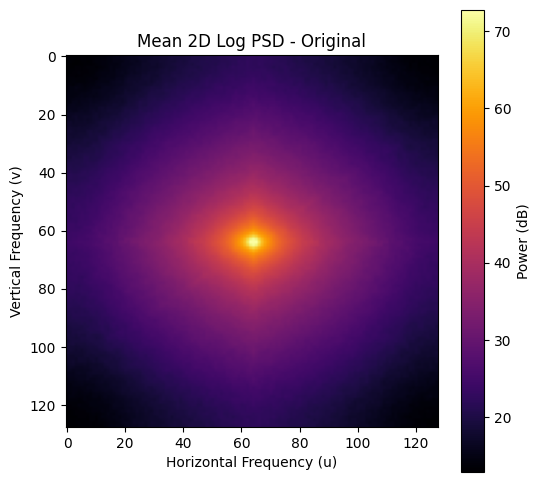

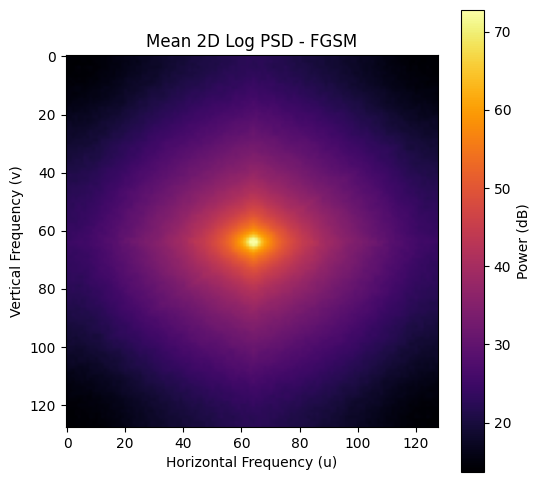

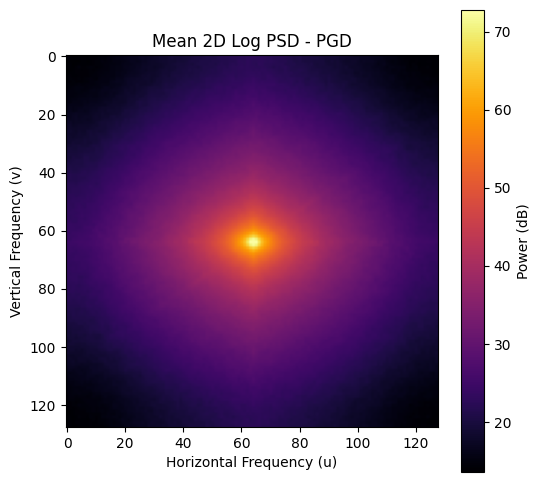

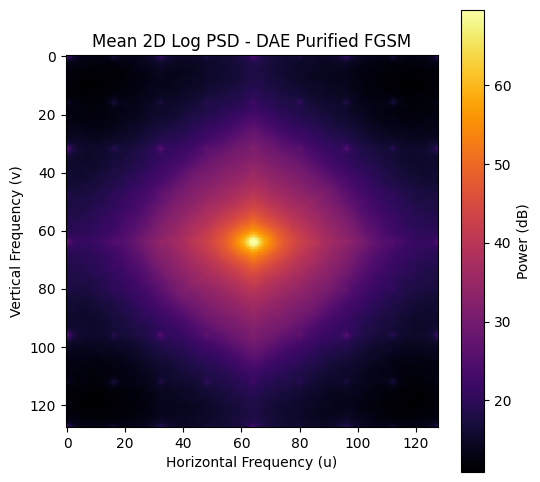

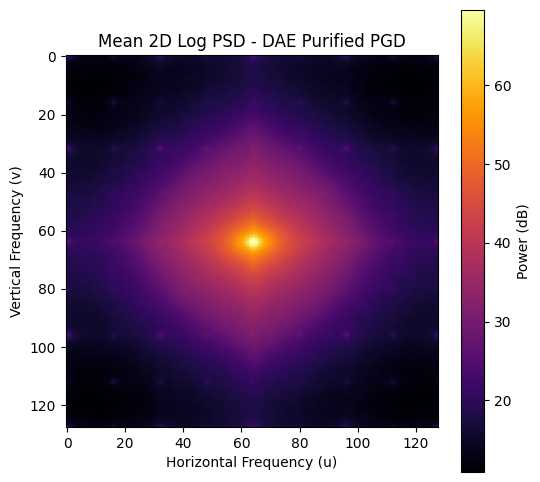

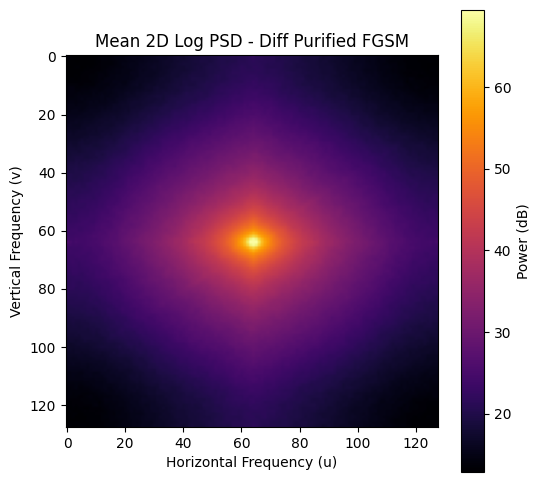

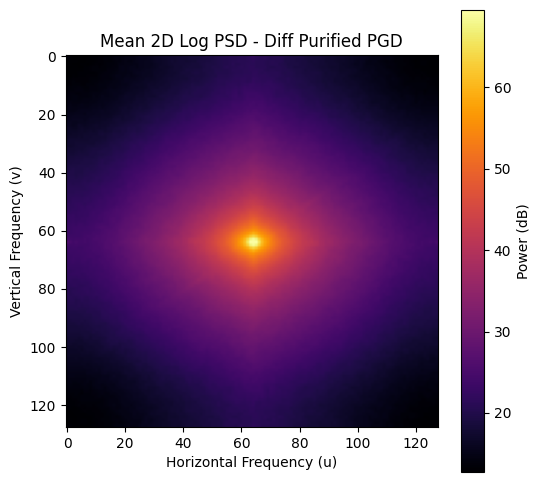

In [16]:
# Extract the underlying image tensors for plotting
original_images, _ = original_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors
dae_purified_fgsm_images, _ = dae_purified_fgsm_loader.dataset.tensors
dae_purified_pgd_images, _ = dae_purified_pgd_loader.dataset.tensors
diff_purified_fgsm_images, _ = diff_purified_fgsm_loader.dataset.tensors
diff_purified_pgd_images, _ = diff_purified_pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(128, 128), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(original_images, title="Mean 2D Log PSD - Original", dataset_name="pets_binary")
analyzer.plot_2d(fgsm_images, title="Mean 2D Log PSD - FGSM", dataset_name="pets_binary")
analyzer.plot_2d(pgd_images, title="Mean 2D Log PSD - PGD", dataset_name="pets_binary")
analyzer.plot_2d(dae_purified_fgsm_images, title="Mean 2D Log PSD - DAE Purified FGSM", dataset_name="pets_binary")
analyzer.plot_2d(dae_purified_pgd_images, title="Mean 2D Log PSD - DAE Purified PGD", dataset_name="pets_binary")
analyzer.plot_2d(diff_purified_fgsm_images, title="Mean 2D Log PSD - Diff Purified FGSM", dataset_name="pets_binary")
analyzer.plot_2d(diff_purified_pgd_images, title="Mean 2D Log PSD - Diff Purified PGD", dataset_name="pets_binary")

In [17]:
# Compare their 1D profiles on the same plot
dae_image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "DAE Purified FGSM": dae_purified_fgsm_images, "DAE Purified PGD": dae_purified_pgd_images}
diff_image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "Diff Purified FGSM": diff_purified_fgsm_images, "Diff Purified PGD": diff_purified_pgd_images}

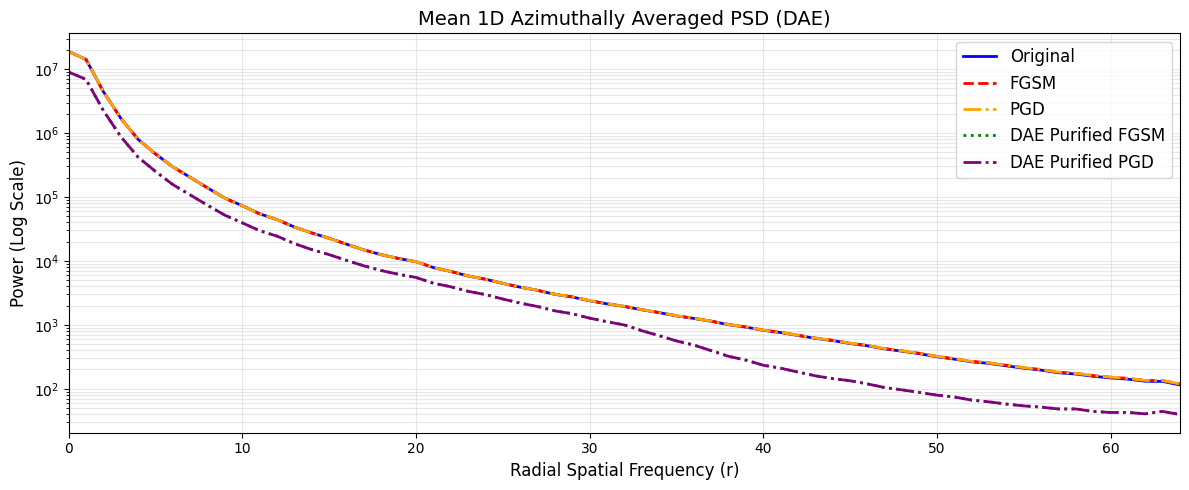

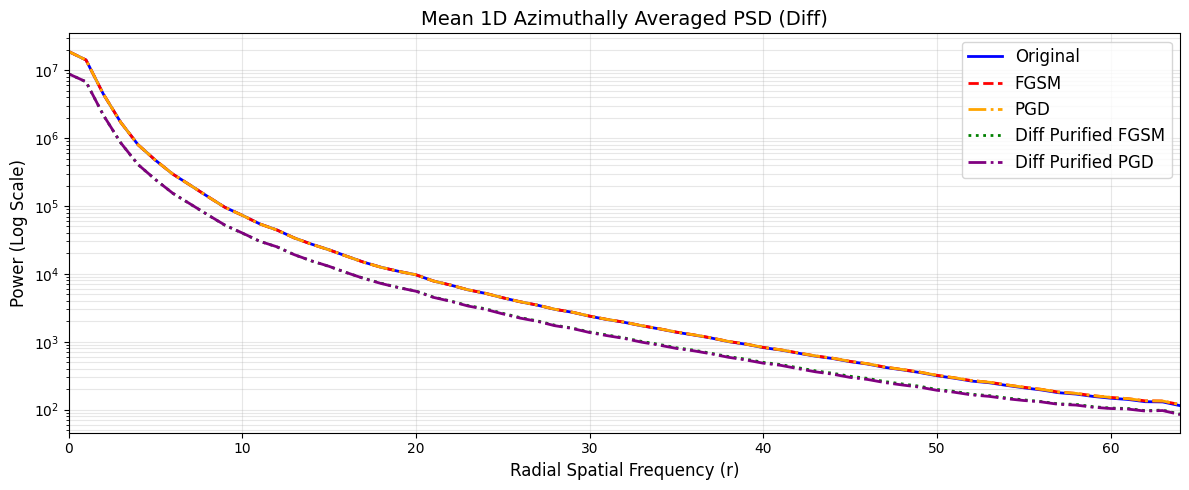

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:231: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=top)


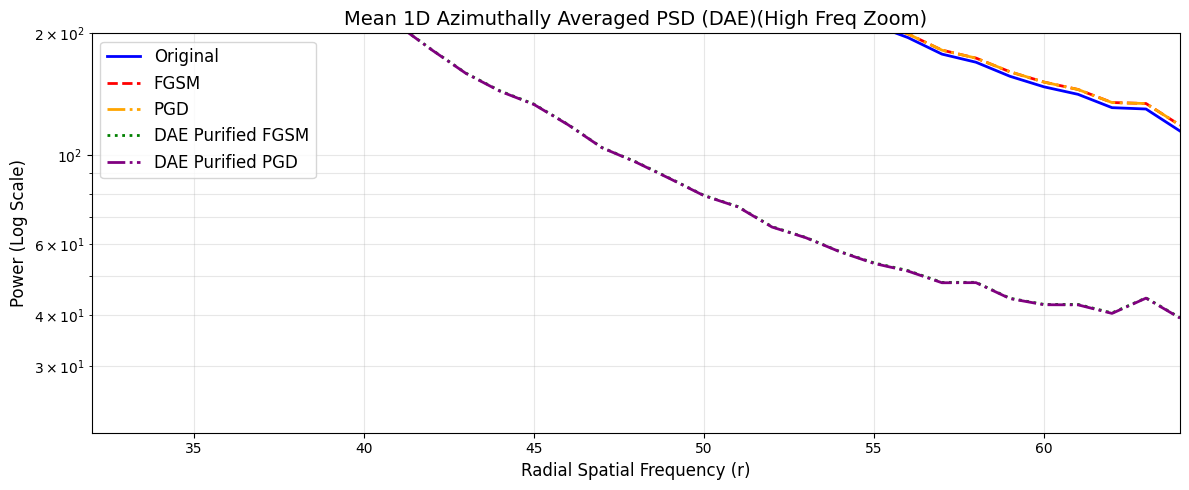

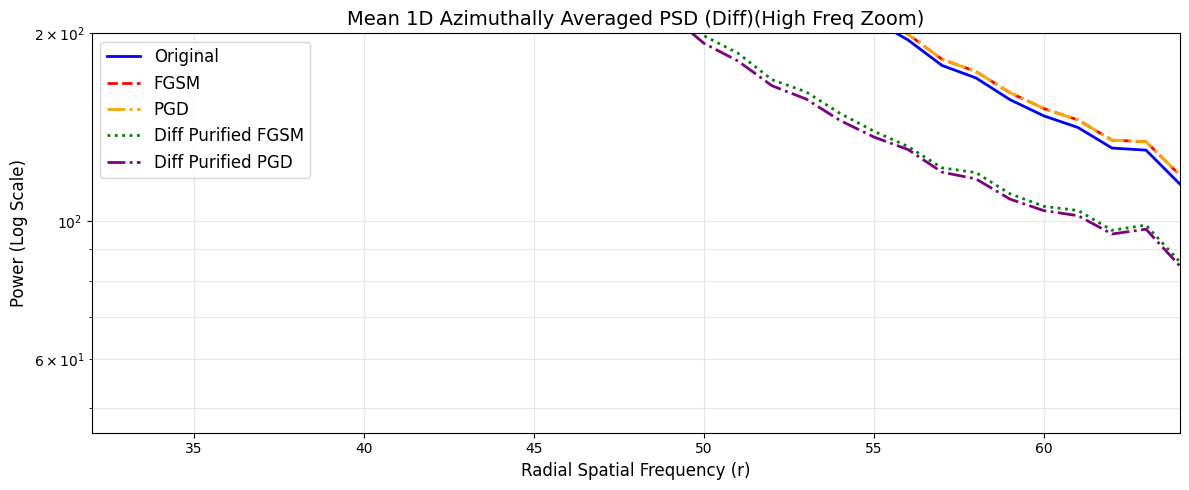

In [18]:
analyzer.plot_1d(dae_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (DAE)", dataset_name="pets_binary")
analyzer.plot_1d(diff_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (Diff)", dataset_name="pets_binary")

# Compare their 1D profiles on the same plot
analyzer.plot_1d(dae_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (DAE)", zoom_high_freq=True, dataset_name="pets_binary")
analyzer.plot_1d(diff_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (Diff)", zoom_high_freq=True, dataset_name="pets_binary")


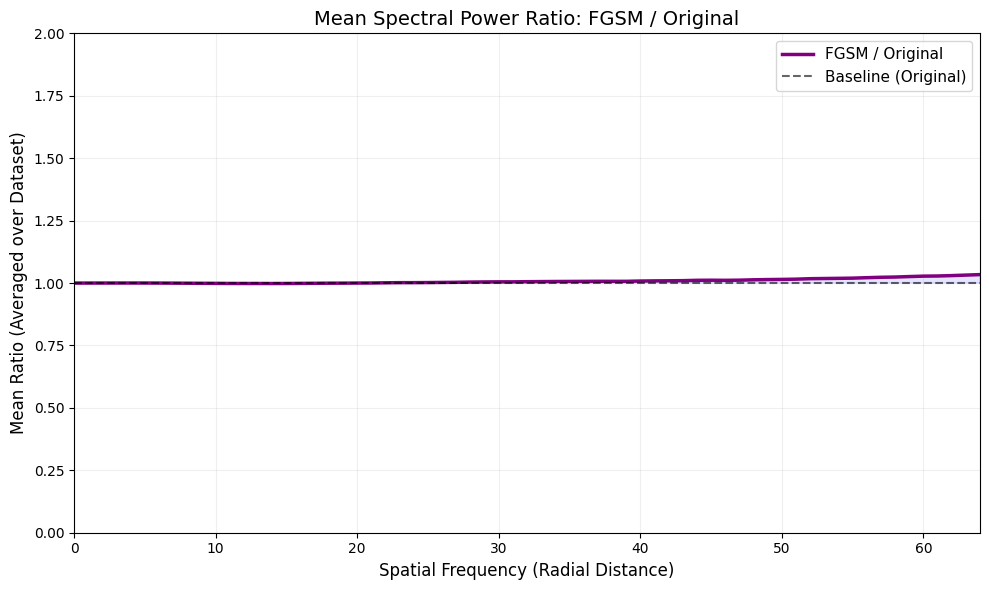

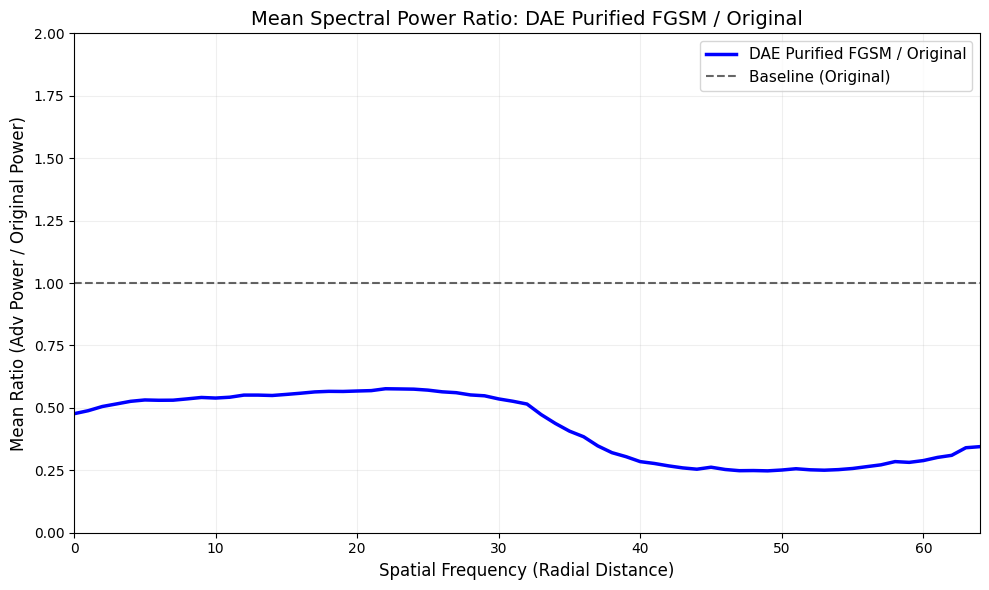

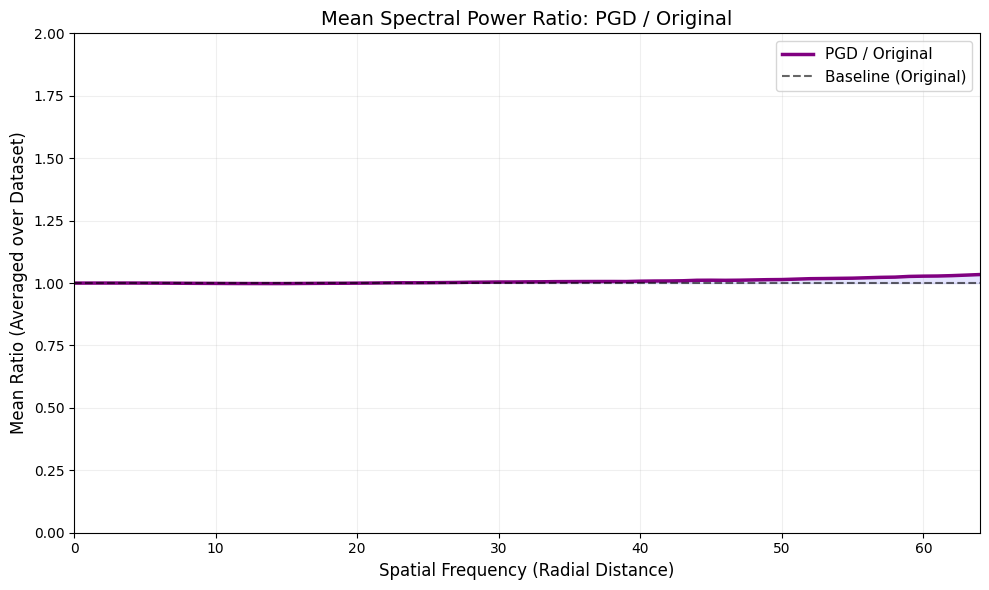

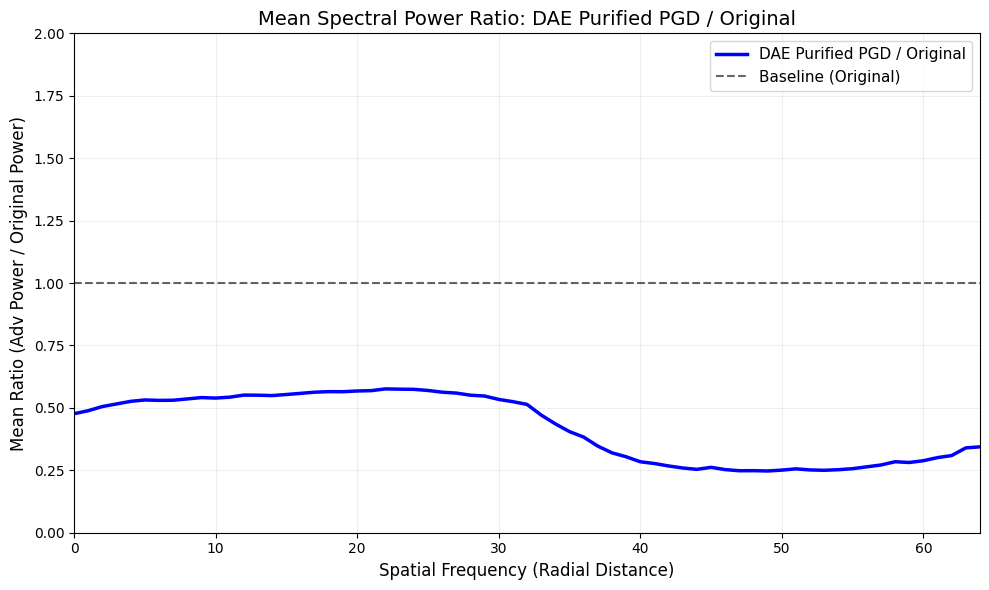

In [19]:
analyzer.plot_1d_ratio(original_images, fgsm_images, dae_purified_fgsm_images, label_21="FGSM / Original", label_31="DAE Purified FGSM / Original", dataset_name="pets_binary")
analyzer.plot_1d_ratio(original_images, pgd_images, dae_purified_pgd_images, label_21="PGD / Original", label_31="DAE Purified PGD / Original", dataset_name="pets_binary")

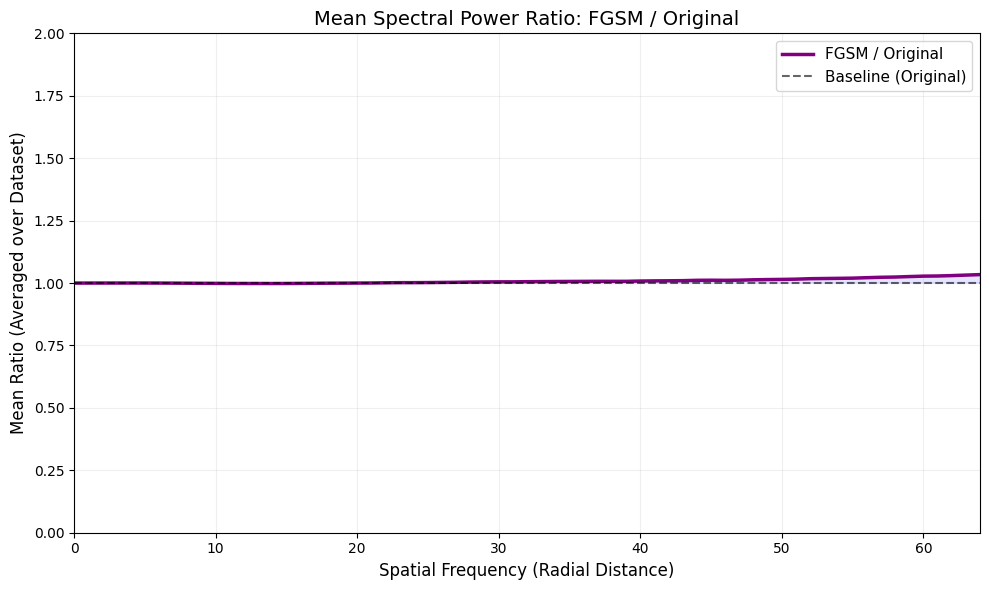

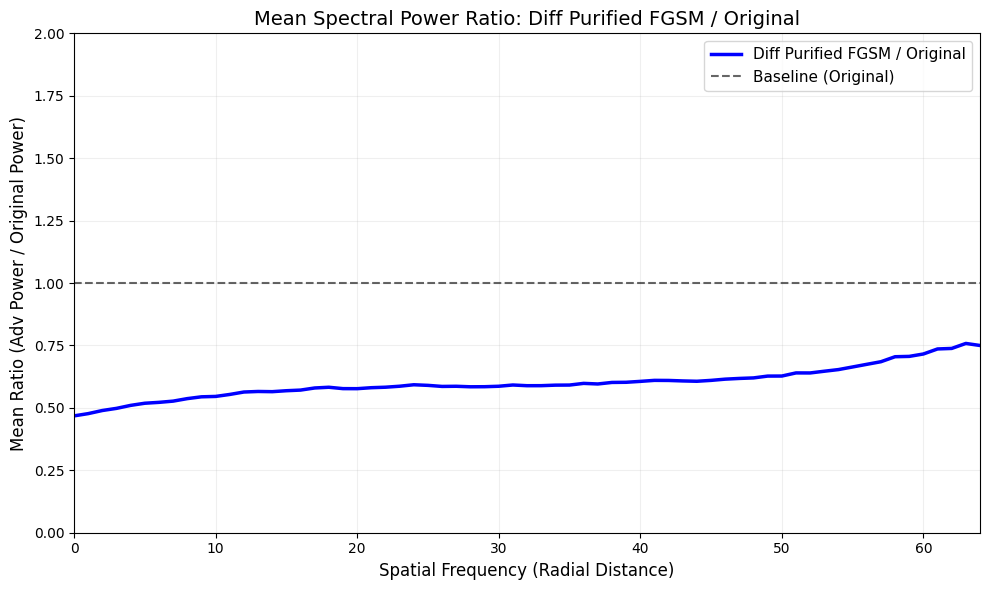

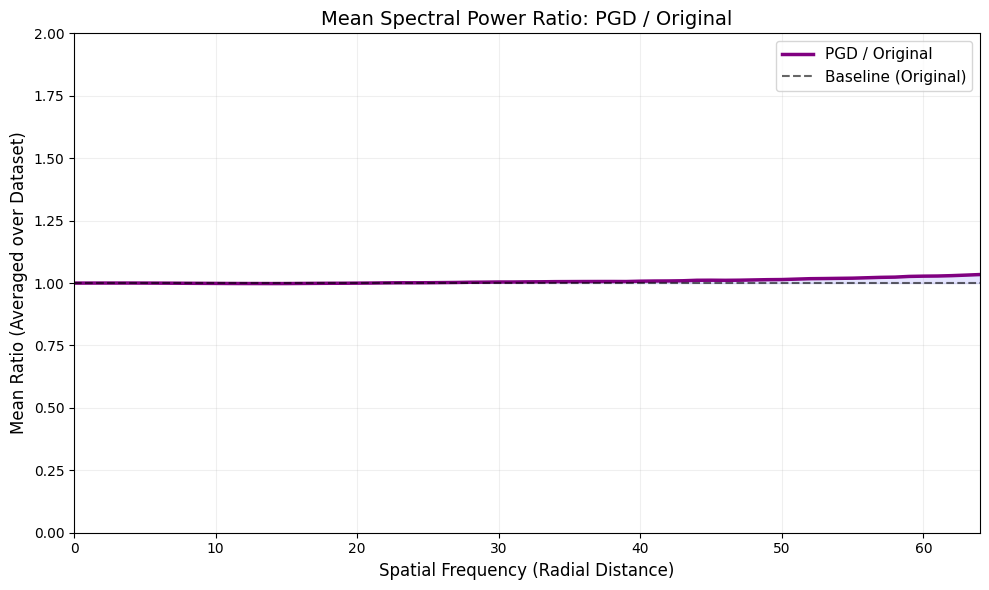

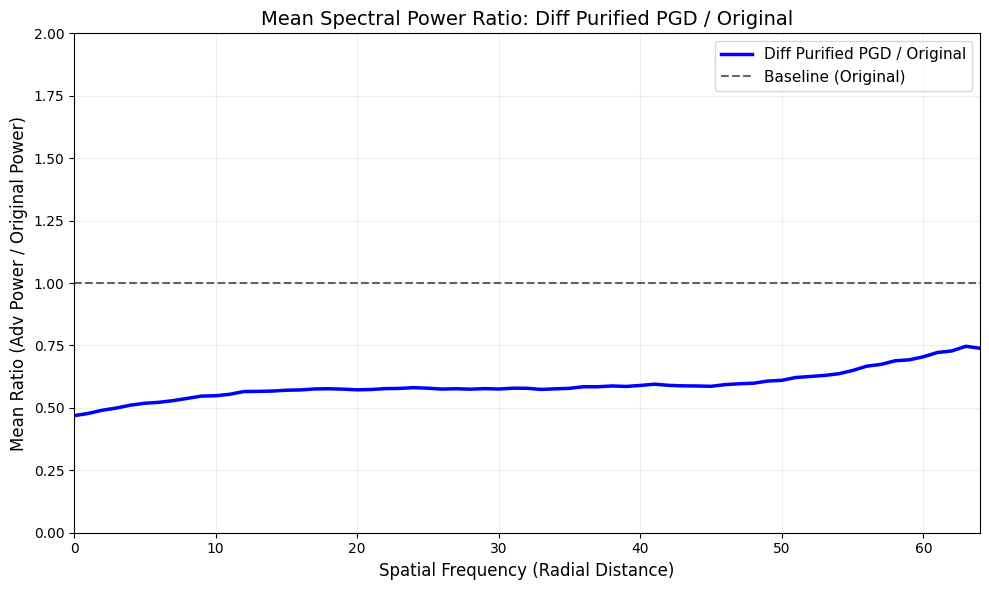

In [20]:
analyzer.plot_1d_ratio(original_images, fgsm_images, diff_purified_fgsm_images, label_21="FGSM / Original", label_31="Diff Purified FGSM / Original", dataset_name="pets_binary")
analyzer.plot_1d_ratio(original_images, pgd_images, diff_purified_pgd_images, label_21="PGD / Original", label_31="Diff Purified PGD / Original", dataset_name="pets_binary")

In [21]:
analyzer.print_spectral_stats(dae_image_label_dict)
analyzer.print_spectral_stats(diff_image_label_dict)

Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 46.0946              | 26.1522             
FGSM       | 46.0962              | 26.2181             
PGD        | 46.0947              | 26.2168             
DAE Purified FGSM | 43.4564              | 20.8764             
DAE Purified PGD | 43.4518              | 20.8670             
Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 46.0946              | 26.1522             
FGSM       | 46.0962              | 26.2181             
PGD        | 46.0947              | 26.2168             
Diff Purified FGSM | 43.5364              | 24.2229             
Diff Purified PGD | 43.5131              | 24.1156             


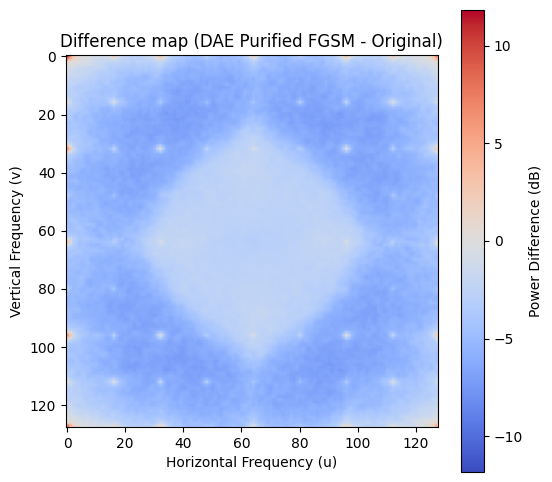

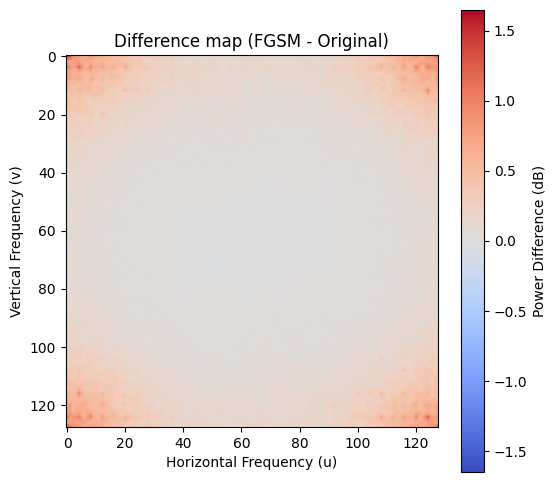

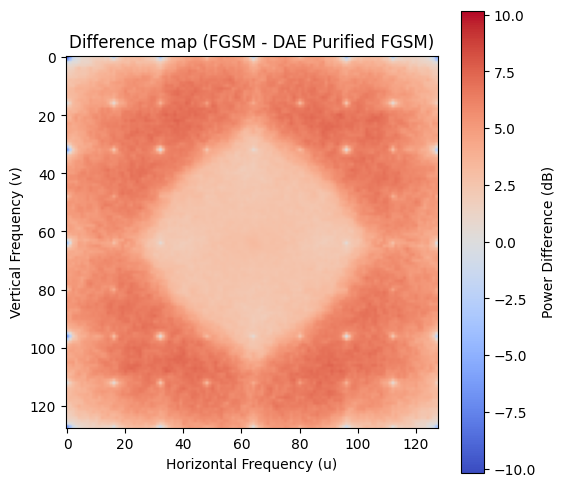

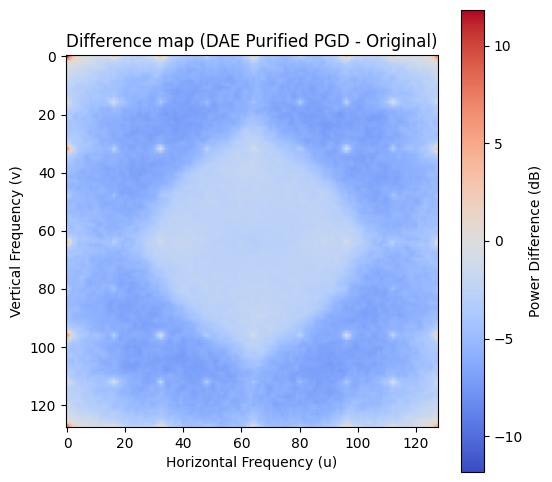

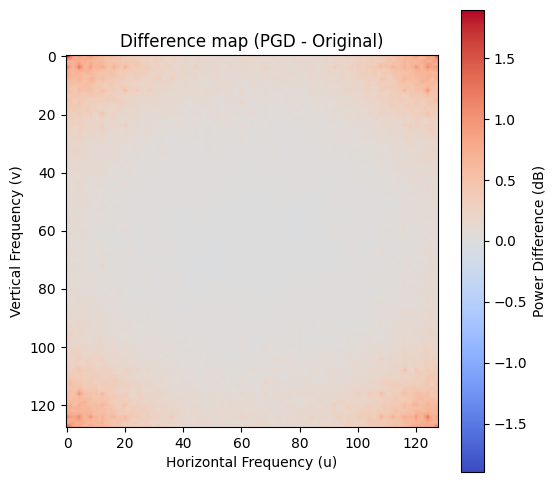

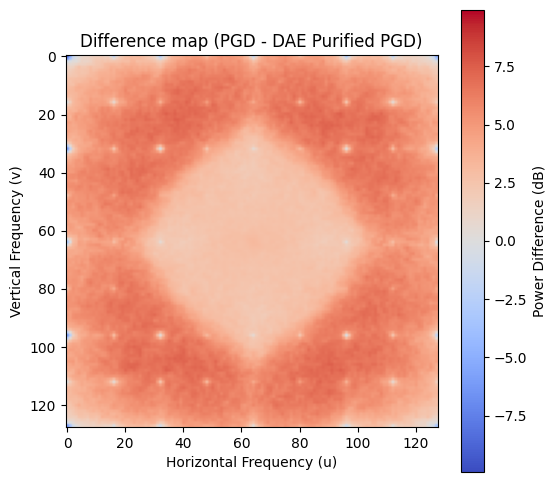

In [22]:
analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=fgsm_images,
    images_2=dae_purified_fgsm_images,
    title_31="Difference map (FGSM - Original)",
    title_21="Difference map (DAE Purified FGSM - Original)",
    title_32="Difference map (FGSM - DAE Purified FGSM)",
    dataset_name="pets_binary"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=pgd_images,
    images_2=dae_purified_pgd_images,
    title_31="Difference map (PGD - Original)",
    title_21="Difference map (DAE Purified PGD - Original)",
    title_32="Difference map (PGD - DAE Purified PGD)",
    dataset_name="pets_binary"
)

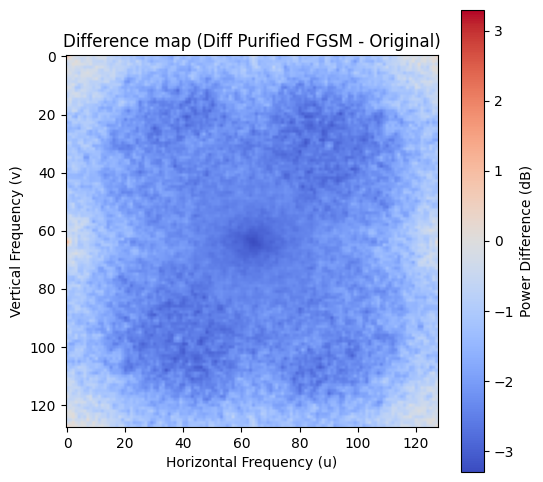

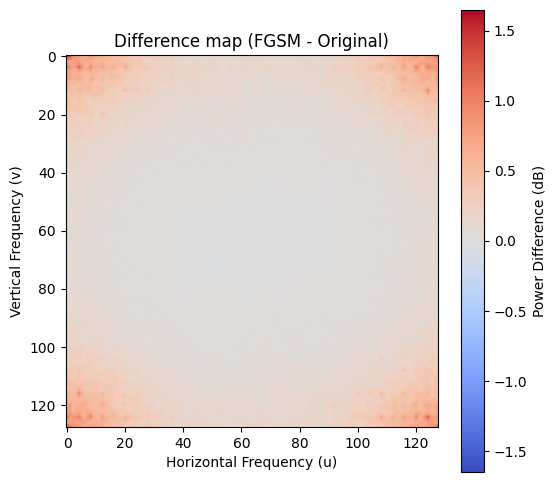

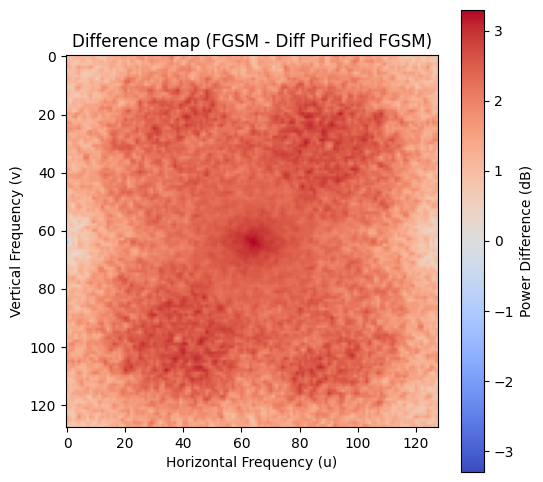

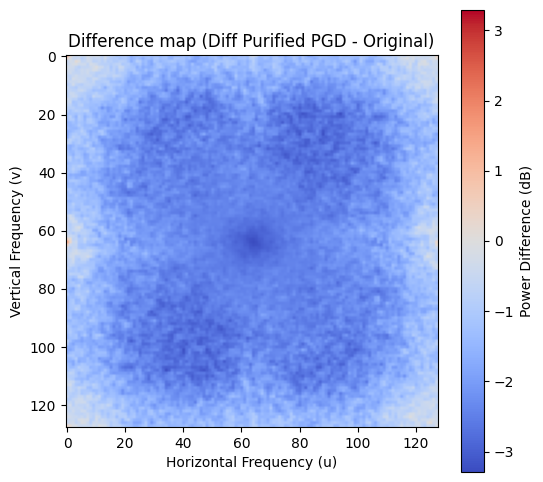

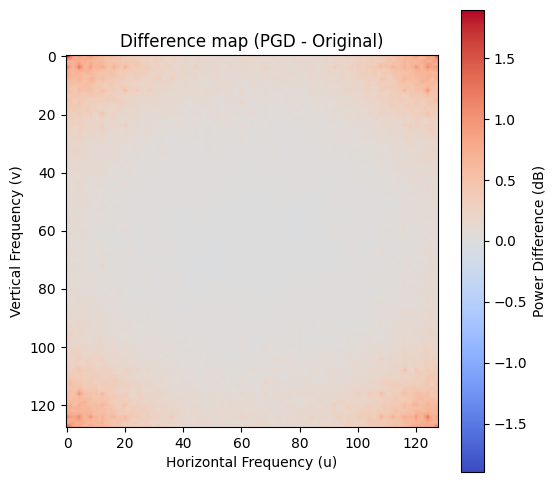

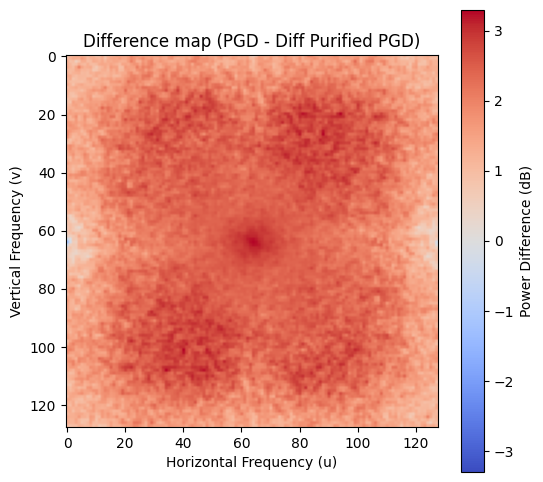

In [23]:
analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=fgsm_images,
    images_2=diff_purified_fgsm_images,
    title_31="Difference map (FGSM - Original)",
    title_21="Difference map (Diff Purified FGSM - Original)",
    title_32="Difference map (FGSM - Diff Purified FGSM)",
    dataset_name="pets_binary"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=pgd_images,
    images_2=diff_purified_pgd_images,
    title_31="Difference map (PGD - Original)",
    title_21="Difference map (Diff Purified PGD - Original)",
    title_32="Difference map (PGD - Diff Purified PGD)",
    dataset_name="pets_binary"
)

In [26]:
def unnormalize_and_prep(tensor_img, mean, std):
    """
    Reverses normalization and formats a single image tensor for Matplotlib.
    """
    img = tensor_img.clone().detach().cpu()
    
    # Un-normalize channel by channel: img = img * std + mean
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
        
    # Clamp to strictly [0, 1] to avoid Matplotlib display warnings
    img = torch.clamp(img, 0.0, 1.0)
    
    # Permute from (C, H, W) to (H, W, C) for Matplotlib
    return img.permute(1, 2, 0).numpy()

def comparison_grid(idx=None, dataset_name="pets_binary"):
    # 1. Ensure you extract the raw image tensors if you haven't already
    # For CIFAR-10, this might be clean_images. For Pets, it's original_images.
    # Let's assume you've grabbed the underlying tensors like this:
    clean_imgs, _ = original_loader.dataset.tensors
    fgsm_imgs, _ = fgsm_loader.dataset.tensors
    pgd_imgs, _ = pgd_loader.dataset.tensors
    # fgsm_cleaned_images and pgd_cleaned_images were created directly in your script

    # 2. Pick a random index
    if not idx:
        idx = random.randint(0, len(clean_imgs) - 1)

    # 3. Define the mean and std used for your dataset
    # ---> IMPORTANT: Set these based on the dataset you are currently running! <---
    # For Pets (ImageNet): mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    # For CIFAR-10:        mean=[0.5, 0.5, 0.5],       std=[0.5, 0.5, 0.5]
    dataset_mean = [0.485, 0.456, 0.406]
    dataset_std = [0.229, 0.224, 0.225]

    # 4. Prepare all 5 images for plotting
    img_orig = unnormalize_and_prep(clean_imgs[idx], dataset_mean, dataset_std)
    img_fgsm = unnormalize_and_prep(fgsm_imgs[idx], dataset_mean, dataset_std)
    img_pgd = unnormalize_and_prep(pgd_imgs[idx], dataset_mean, dataset_std)
    img_daepure_fgsm = unnormalize_and_prep(dae_purified_fgsm_images[idx], dataset_mean, dataset_std)
    img_daepure_pgd = unnormalize_and_prep(dae_purified_pgd_images[idx], dataset_mean, dataset_std)
    img_diffpure_fgsm = unnormalize_and_prep(diff_purified_fgsm_images[idx], dataset_mean, dataset_std)
    img_diffpure_pgd = unnormalize_and_prep(diff_purified_pgd_images[idx], dataset_mean, dataset_std)

    # 5. Plot them side-by-side
    fig, axes = plt.subplots(1, 7, figsize=(18, 4))
    images_to_plot = [img_orig, img_fgsm, img_pgd, img_daepure_fgsm, img_daepure_pgd, img_diffpure_fgsm, img_diffpure_pgd]
    titles = [
        "Original", 
        "FGSM Adversarial", 
        "PGD Adversarial", 
        "DAE Purified FGSM",
        "DAE Purified PGD",
        "Diff Purified FGSM", 
        "Diff Purified PGD"
    ]

    for ax, img, title in zip(axes, images_to_plot, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"../figs/{dataset_name}/images/image_comparison_grid_{idx}.png")
    plt.show()


Generating visual comparison grid...
[667  61 571 612 452]


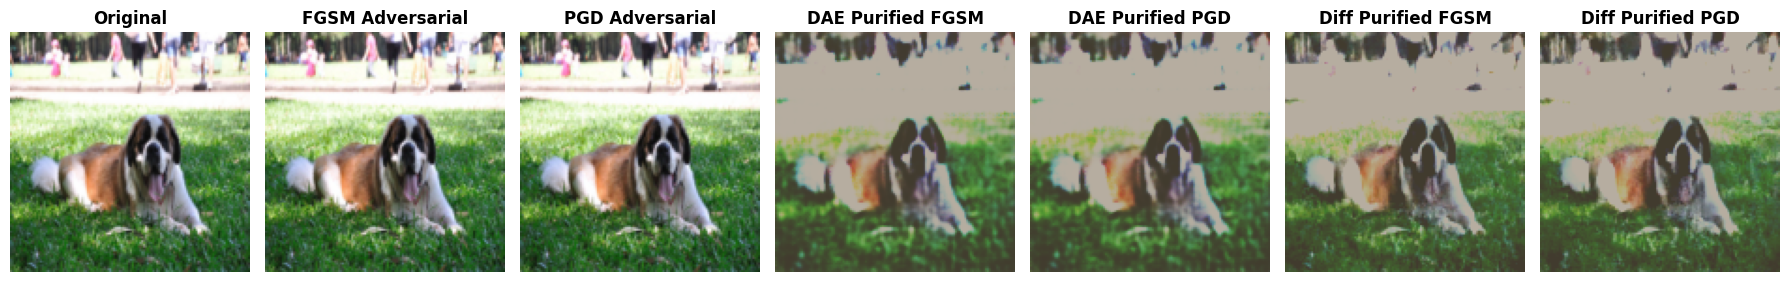

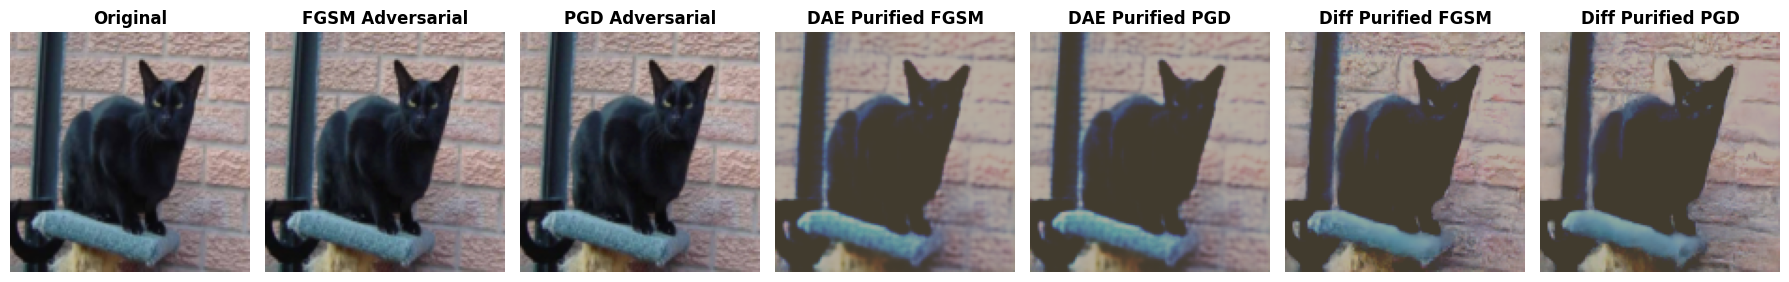

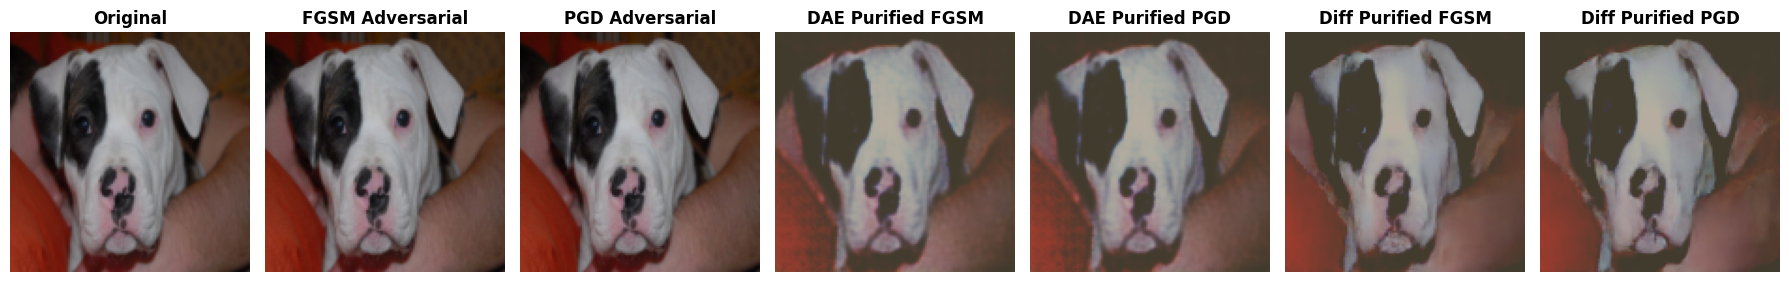

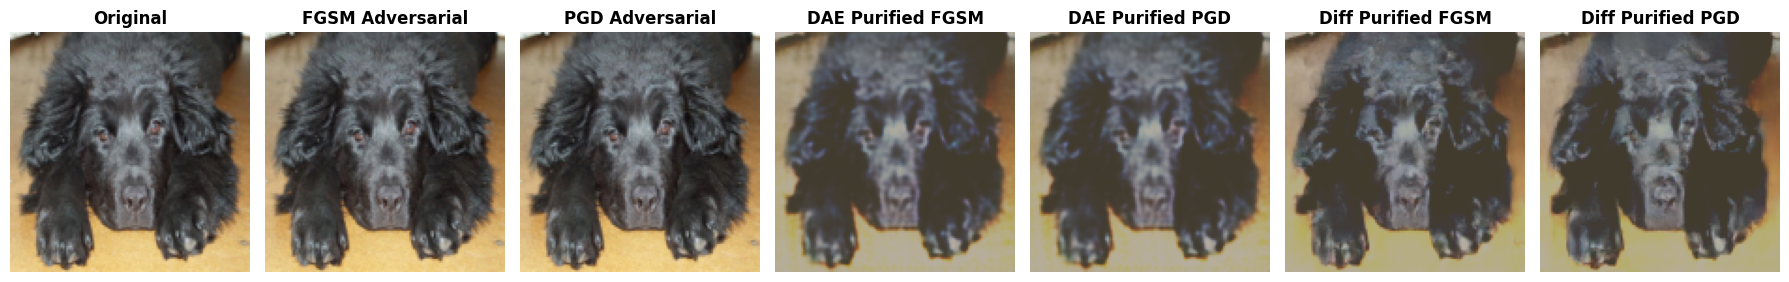

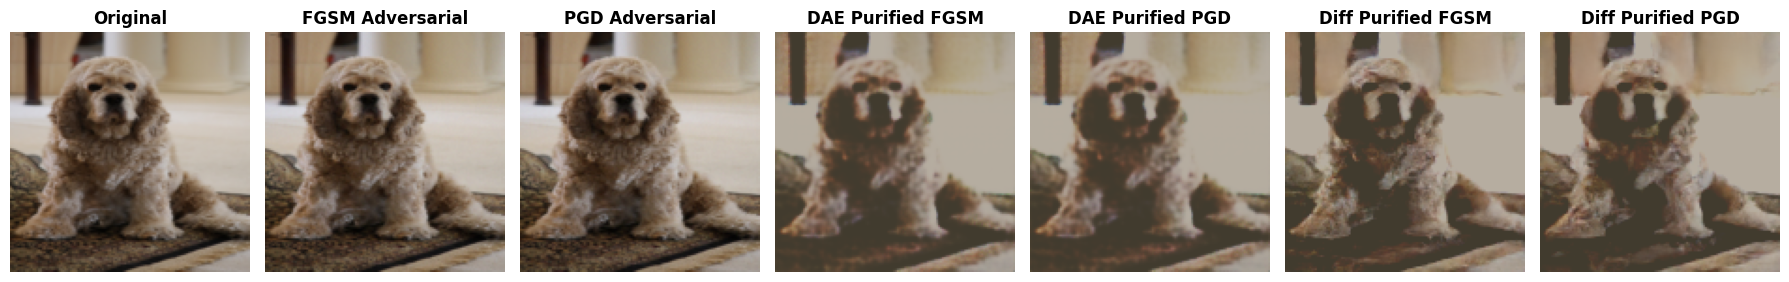

In [28]:
print("\nGenerating visual comparison grid...")

idxs = np.random.randint(0, len(original_loader.dataset.tensors[0]) - 1, 5)
print(idxs)
for idx in idxs:
    comparison_grid(idx)